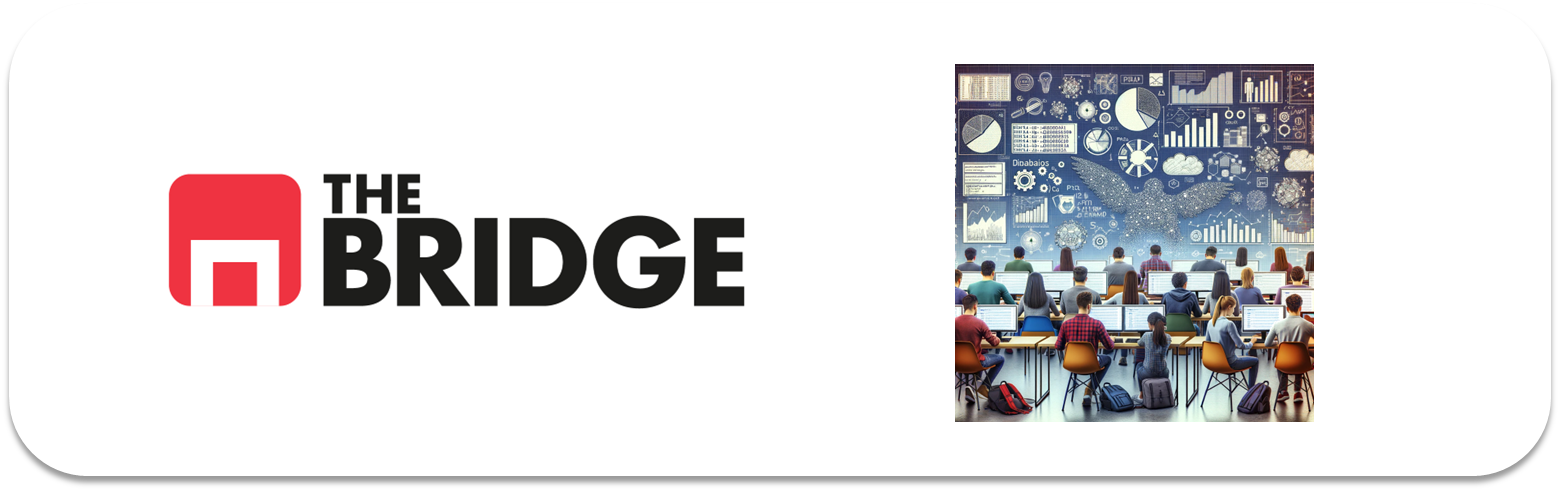

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hard_to_find/obligatoria_hard.csv", sep="|")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [5]:
df.shape

(506, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


## División de los datos en Train y test

- la variable objetivo es `MEDV`, ya que representa el valor media de las viviendas y es la variable que queremos predecir.
- separamos las variables predictoras (`x`) de la variable objetivo (`y`) antes de dividir los datos en los conjuntos de entrenamiento y test. 

In [7]:
#Features

x = df.drop(columns = "MEDV")

#target
y = df["MEDV"]


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [10]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (404, 12)
X_test: (102, 12)
y_train: (404,)
y_test: (102,)


## Mini-EDA sobre TRAIN
## Análisis de variable Target: MEDV
Analizamos la distribucion de la variable objetivo `MEDV`utilizando unicamente los datos de entrenamiento, manteniendo el conjunto de test reservado para la evaluacion final del modelo.

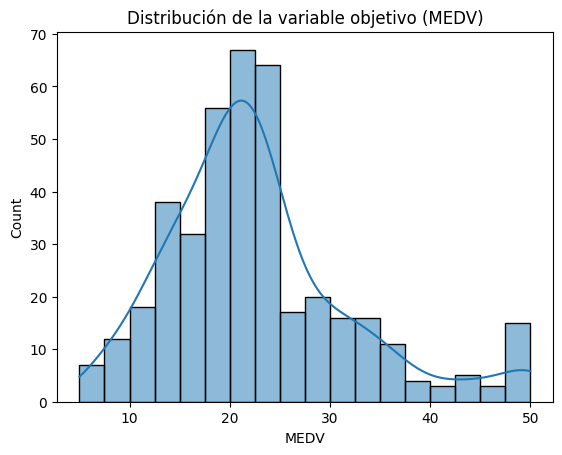

In [11]:
sns.histplot(y_train, kde=True)
plt.xlabel("MEDV")
plt.title("Distribución de la variable objetivo (MEDV)")
plt.show()

**Conclusión:** La variable objetivo `MEDV` presenta una distribución unimodal, aunque no es perfectamente normal y muestra cierta asimetría hacia la derecha. La mayor parte de los valores se concentra aproximadamente entre 15 y 25, observándose además una acumulación de valores en torno a 50. Aun así, consideramos adecuado continuar con un modelo de regresión lineal y posteriormente evaluaremos su rendimiento mediante las métricas correspondientes.

## 3.2 Matriz de correlaciones

In [13]:
train_set = x_train.copy()
train_set["MEDV"] = y_train

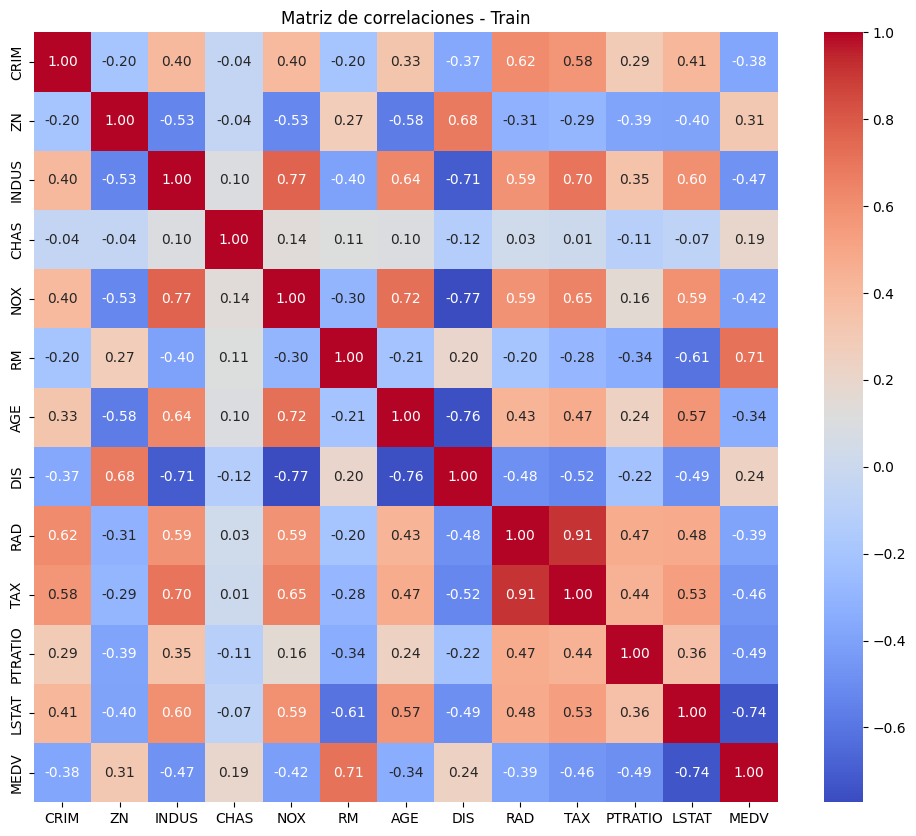

In [14]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    train_set.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlaciones - Train")
plt.show()

### Análisis de correlaciones

- Las variables que presentan una mayor correlación con la variable objetivo `MEDV` son `LSTAT` (-0.74) y `RM` (0.71), por lo que inicialmente parecen ser las variables con mayor relación lineal con el precio de las viviendas.

- También se observan correlaciones elevadas entre algunas variables predictoras. Destaca especialmente la relación entre `RAD` y `TAX` (0.91), además de otras relaciones elevadas entre variables como `NOX`, `DIS`, `AGE` e `INDUS`.

- Estas relaciones pueden indicar cierta colinealidad entre las variables predictoras, aspecto que tendremos en cuenta posteriormente al evaluar el modelo y aplicar regularización.

## Modelo baseline: Regresión Lineal

Como primer modelo se utilizará una regresión lineal con todas las variables predictoras disponibles.

El dataset no presenta valores nulos y todas las variables son numéricas, por lo que no es necesario realizar transformaciones adicionales para entrenar este primer modelo.

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_train = lr.predict(x_train)
y_pred_test = lr.predict(x_test)

In [24]:
from sklearn import metrics

print("TRAIN")
print("MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("R2:", lr.score(x_train, y_train))

TRAIN
MAE: 3.4244687759495283
MSE: 22.60428647941742
RMSE: 4.754396542087904
R2: 0.739801993681731


In [25]:
print("TEST")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("R2:", lr.score(x_test, y_test))

TEST
MAE: 3.111377388238152
MSE: 22.777708563865886
RMSE: 4.7725997699226665
R2: 0.6893967884614781


### Evaluación del modelo baseline

- El modelo de regresión lineal obtiene resultados similares entre los conjuntos de entrenamiento y test. El RMSE es de aproximadamente 4.75 en Train y 4.77 en Test, mientras que el MSE apenas varía entre ambos conjuntos.

- El R² pasa de 0.74 en Train a 0.69 en Test, mostrando una ligera pérdida de rendimiento sobre datos no utilizados durante el entrenamiento, pero sin observarse una diferencia elevada entre los errores de Train y Test.

- En Test, el MAE es aproximadamente 3.11, lo que supone un error absoluto medio de unos 3.11 miles de dólares en la predicción de `MEDV`.

- En conjunto, el modelo baseline presenta una capacidad de generalización razonable y no muestra indicios claros de un sobreajuste elevado.

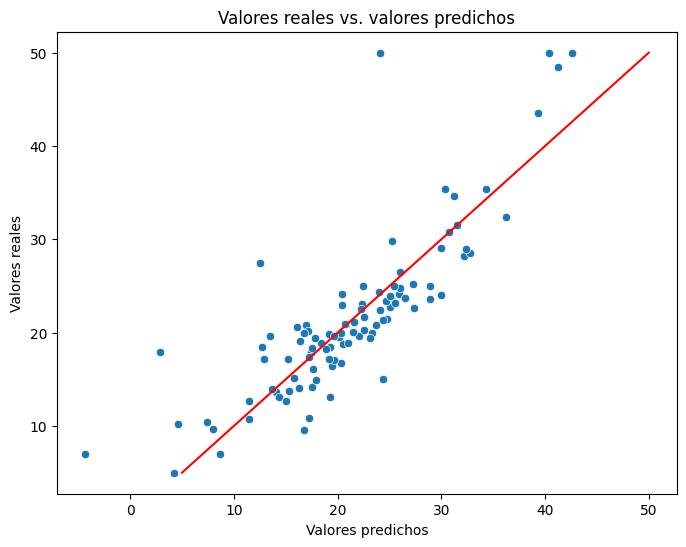

In [26]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred_test, y=y_test)

plt.xlabel("Valores predichos")
plt.ylabel("Valores reales")
plt.title("Valores reales vs. valores predichos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "red"
)

plt.show()

### Comparación entre valores reales y predichos

- La mayoría de las predicciones se encuentran próximas a la diagonal, lo que indica que el modelo de regresión lineal consigue aproximarse razonablemente a los valores reales.

- Sin embargo, se observan algunos puntos alejados de la línea, especialmente en valores altos de MEDV, donde el modelo tiende en algunos casos a infravalorar el precio real.

- Esto es coherente con las métricas obtenidas: el modelo presenta una capacidad predictiva razonable, aunque todavía existen observaciones con errores elevados.

In [29]:
coef_df = pd.DataFrame(
    lr.coef_,
    index=x_train.columns,
    columns=["Coefficient"]
)

coef_df.sort_values("Coefficient", ascending=False)

,Coefficient
RM,4.240098
CHAS,3.049477
RAD,0.239990
ZN,0.030795
INDUS,0.025248
AGE,-0.003594
TAX,-0.011275
CRIM,-0.127196
LSTAT,-0.537770
PTRATIO,-0.894845


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [34]:
X_train_scaled[:5]

array([[ 1.28770177, -0.50032012,  1.03323679, -0.27808871,  0.48925206,
        -1.42806858,  1.02801516, -0.80217296,  1.70689143,  1.57843444,
         0.84534281,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, -0.27808871, -0.15723342,
        -0.68008655, -0.43119908,  0.32434893, -0.62435988, -0.58464788,
         1.20474139, -0.5614742 ],
       [-0.40325332,  1.01327135, -0.71521823, -0.27808871, -1.00872286,
        -0.40206304, -1.6185989 ,  1.3306972 , -0.97404758, -0.60272378,
        -0.63717631, -0.65159505],
       [ 0.38822983, -0.50032012,  1.03323679, -0.27808871,  0.48925206,
        -0.30045039,  0.59168149, -0.8392398 ,  1.70689143,  1.57843444,
         0.84534281,  1.52538664],
       [-0.32528234, -0.50032012, -0.41315956, -0.27808871, -0.15723342,
        -0.83109424,  0.03374663, -0.00549428, -0.62435988, -0.58464788,
         1.20474139, -0.16578736]])

In [35]:
lr_scaled = LinearRegression()

lr_scaled.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-1.13, 0.71, 0.17,...,-1.87,-1.99,-3.82]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[48.47,24.25,22.14,..., 8.51, 8.25, 5.07]"


In [37]:
coef_scaled = pd.DataFrame(
    lr_scaled.coef_,
    index=x_train.columns,
    columns=["Coefficient_scaled"]
)

coef_scaled.sort_values("Coefficient_scaled", ascending=False)

,Coefficient_scaled
RM,3.004420
RAD,2.058898
CHAS,0.787152
ZN,0.712109
INDUS,0.173858
AGE,-0.100500
CRIM,-1.127473
TAX,-1.871317
PTRATIO,-1.991871
NOX,-2.137599


### Importancia de las variables

- Tras estandarizar las variables predictoras, los coeficientes pueden compararse mejor al encontrarse las features en una escala común.

- Las variables con mayor peso en valor absoluto son `LSTAT`, `DIS` y `RM`. `LSTAT` y `DIS` presentan coeficientes negativos, mientras que `RM` presenta un coeficiente positivo.

- Por otro lado, variables como `AGE` e `INDUS` presentan coeficientes de menor magnitud en este modelo.

- Los resultados son coherentes en parte con el análisis de correlaciones realizado previamente, donde `LSTAT` y `RM` mostraban una relación elevada con la variable objetivo `MEDV`.

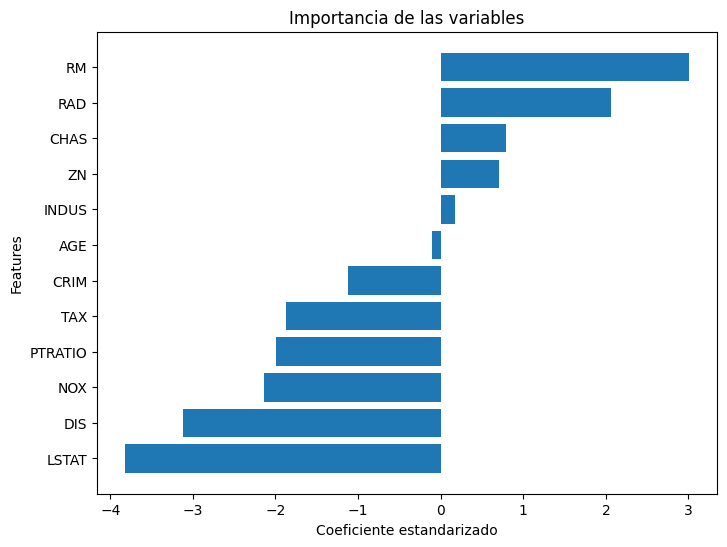

In [38]:
features = coef_scaled.sort_values("Coefficient_scaled")

plt.figure(figsize=(8, 6))
plt.barh(features.index, features["Coefficient_scaled"])
plt.xlabel("Coeficiente estandarizado")
plt.ylabel("Features")
plt.title("Importancia de las variables")
plt.show()

### Interpretación de los coeficientes estandarizados

- El gráfico permite comparar el peso de las variables al haber sido previamente estandarizadas.

- `RM` presenta uno de los mayores coeficientes positivos, por lo que un aumento de esta variable contribuye a incrementar la predicción de `MEDV`.

- Por el contrario, `LSTAT` presenta el coeficiente negativo de mayor magnitud, seguido de `DIS`, por lo que incrementos en estas variables contribuyen a reducir la predicción del modelo.

- Variables como `AGE` e `INDUS` presentan coeficientes cercanos a cero, indicando un menor peso dentro de este modelo.

- El signo del coeficiente indica la dirección de su efecto, mientras que su magnitud permite comparar el peso relativo de las variables una vez estandarizadas.

In [39]:
from sklearn.linear_model import Ridge

ridge_1 = Ridge(alpha=1)

ridge_1.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [47]:
y_pred_ridge_train = ridge_1.predict(X_train_scaled)
y_pred_ridge_test = ridge_1.predict(X_test_scaled)

In [49]:
print("BASELINE vs RIDGE alpha = 1")

print("\n--- TRAIN ---")
print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Ridge MSE:", metrics.mean_squared_error(y_train, y_pred_ridge_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_ridge_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Ridge R2:", ridge_1.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Ridge MAE:", metrics.mean_absolute_error(y_test, y_pred_ridge_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Ridge MSE:", metrics.mean_squared_error(y_test, y_pred_ridge_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Ridge R2:", ridge_1.score(X_test_scaled, y_test))

BASELINE vs RIDGE alpha = 1

--- TRAIN ---
Baseline MSE: 22.60428647941742
Ridge MSE: 22.605620625168353
Baseline RMSE: 4.754396542087904
Ridge RMSE: 4.754536846546502
Baseline R2: 0.739801993681731
Ridge R2: 0.739786636326176

--- TEST ---
Baseline MAE: 3.111377388238152
Ridge MAE: 3.107353468105829
Baseline MSE: 22.777708563865886
Ridge MSE: 22.811118721558383
Baseline RMSE: 4.7725997699226665
Ridge RMSE: 4.776098692610778
Baseline R2: 0.6893967884614781
Ridge R2: 0.6889411981966277


In [42]:
ridge_10 = Ridge(alpha=10)

ridge_10.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [43]:
y_pred_ridge10_train = ridge_10.predict(X_train_scaled)
y_pred_ridge10_test = ridge_10.predict(X_test_scaled)

In [52]:
print("BASELINE vs RIDGE alpha = 10")

print("\n--- TRAIN ---")
print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Ridge MSE:", metrics.mean_squared_error(y_train, y_pred_ridge10_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_ridge10_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Ridge R2:", ridge_10.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Ridge MAE:", metrics.mean_absolute_error(y_test, y_pred_ridge10_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Ridge MSE:", metrics.mean_squared_error(y_test, y_pred_ridge10_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge10_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Ridge R2:", ridge_10.score(X_test_scaled, y_test))

BASELINE vs RIDGE alpha = 10

--- TRAIN ---
Baseline MSE: 22.60428647941742
Ridge MSE: 22.694169686958574
Baseline RMSE: 4.754396542087904
Ridge RMSE: 4.763839804921926
Baseline R2: 0.739801993681731
Ridge R2: 0.7387673478226372

--- TEST ---
Baseline MAE: 3.111377388238152
Ridge MAE: 3.085876006181848
Baseline MSE: 22.777708563865886
Ridge MSE: 23.092579748945866
Baseline RMSE: 4.7725997699226665
Ridge RMSE: 4.805473935934505
Baseline R2: 0.6893967884614781
Ridge R2: 0.6851031168205155


In [53]:
ridge_100 = Ridge(alpha=100)

ridge_100.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [54]:
y_pred_ridge100_train = ridge_100.predict(X_train_scaled)
y_pred_ridge100_test = ridge_100.predict(X_test_scaled)

In [57]:
print("BASELINE vs RIDGE alpha = 100")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Ridge MAE:", metrics.mean_absolute_error(y_train, y_pred_ridge100_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Ridge MSE:", metrics.mean_squared_error(y_train, y_pred_ridge100_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_ridge100_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Ridge R2:", ridge_100.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Ridge MAE:", metrics.mean_absolute_error(y_test, y_pred_ridge100_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Ridge MSE:", metrics.mean_squared_error(y_test, y_pred_ridge100_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Ridge RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge100_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Ridge R2:", ridge_100.score(X_test_scaled, y_test))

BASELINE vs RIDGE alpha = 100

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Ridge MAE: 3.455252475954835
Baseline MSE: 22.60428647941742
Ridge MSE: 24.66835840730484
Baseline RMSE: 4.754396542087904
Ridge RMSE: 4.966725118959659
Baseline R2: 0.739801993681731
Ridge R2: 0.7160424558160768

--- TEST ---
Baseline MAE: 3.111377388238152
Ridge MAE: 3.1093492393935898
Baseline MSE: 22.777708563865886
Ridge MSE: 24.531560658499885
Baseline RMSE: 4.7725997699226665
Ridge RMSE: 4.952934550193439
Baseline R2: 0.6893967884614781
Ridge R2: 0.665480770235612


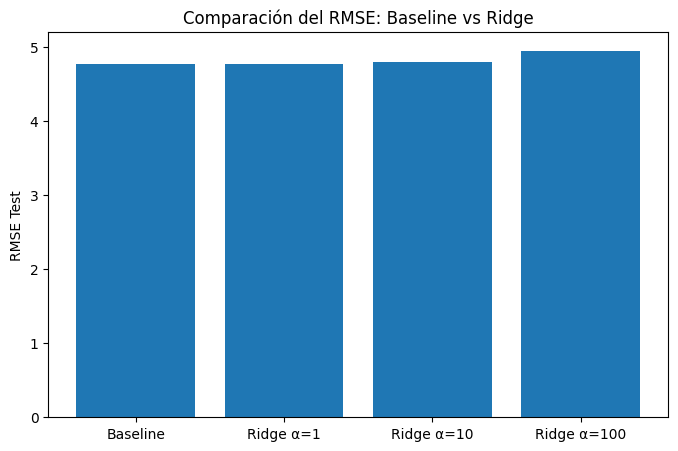

In [59]:
modelos = ["Baseline", "Ridge α=1", "Ridge α=10", "Ridge α=100"]

rmse_test = [
    np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)),
    np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge_test)),
    np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge10_test)),
    np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge100_test))
]

plt.figure(figsize=(8, 5))
plt.bar(modelos, rmse_test)

plt.ylabel("RMSE Test")
plt.title("Comparación del RMSE: Baseline vs Ridge")
plt.show()

### Comparación de la regularización Ridge

- Se probaron tres intensidades de regularización mediante los valores de `alpha` 1, 10 y 100.

- Con `alpha=1`, el rendimiento es prácticamente idéntico al modelo de regresión lineal baseline. Al aumentar `alpha` a 10, el MAE de Test mejora ligeramente, pero empeoran el MSE, RMSE y R², por lo que no se observa una mejora global del modelo.

- Con `alpha=100`, el deterioro de las métricas es más evidente: aumenta el error y disminuye el R² tanto en Train como en Test. Esto indica que una regularización demasiado fuerte está simplificando excesivamente el modelo.

- Por tanto, en estas pruebas Ridge no mejora de forma global el rendimiento del modelo baseline. Los resultados también son coherentes con el hecho de que la regresión lineal inicial no presentaba un sobreajuste elevado.

In [61]:
X_train_reduced = x_train.drop(columns="AGE")
X_test_reduced = x_test.drop(columns="AGE")

In [64]:
print(x_train.shape)
print(X_train_reduced.shape)

(404, 12)
(404, 11)


In [65]:
lr_reduced = LinearRegression()

lr_reduced.fit(X_train_reduced, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-0.13, 0.03, 0.02,...,-0.01,-0.9 ,-0.54]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['CRIM','ZN','INDUS',...,'TAX','PTRATIO','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [66]:
y_pred_reduced_train = lr_reduced.predict(X_train_reduced)
y_pred_reduced_test = lr_reduced.predict(X_test_reduced)

In [69]:
print("BASELINE vs MODELO SIN AGE")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Sin AGE MAE:", metrics.mean_absolute_error(y_train, y_pred_reduced_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Sin AGE MSE:", metrics.mean_squared_error(y_train, y_pred_reduced_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Sin AGE RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_reduced_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Sin AGE R2:", lr_reduced.score(X_train_reduced, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Sin AGE MAE:", metrics.mean_absolute_error(y_test, y_pred_reduced_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Sin AGE MSE:", metrics.mean_squared_error(y_test, y_pred_reduced_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Sin AGE RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_reduced_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Sin AGE R2:", lr_reduced.score(X_test_reduced, y_test))

BASELINE vs MODELO SIN AGE

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Sin AGE MAE: 3.425107411443839
Baseline MSE: 22.60428647941742
Sin AGE MSE: 22.607671277938095
Baseline RMSE: 4.754396542087904
Sin AGE RMSE: 4.754752493867382
Baseline R2: 0.739801993681731
Sin AGE R2: 0.7397630312562782

--- TEST ---
Baseline MAE: 3.111377388238152
Sin AGE MAE: 3.1049030934126165
Baseline MSE: 22.777708563865886
Sin AGE MSE: 22.710489158310484
Baseline RMSE: 4.7725997699226665
Sin AGE RMSE: 4.765552345563994
Baseline R2: 0.6893967884614781
Sin AGE R2: 0.6903134110964845


In [70]:
X_train_reduced2 = X_train_reduced.drop(columns="INDUS")
X_test_reduced2 = X_test_reduced.drop(columns="INDUS")

print(X_train_reduced.shape)
print(X_train_reduced2.shape)

(404, 11)
(404, 10)


In [71]:
lr_reduced2 = LinearRegression()

lr_reduced2.fit(X_train_reduced2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.13, 0.03, 3.08,...,-0.01,-0.89,-0.54]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['CRIM','ZN','CHAS',...,'TAX','PTRATIO','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,36.96
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [72]:
y_pred_reduced2_train = lr_reduced2.predict(X_train_reduced2)
y_pred_reduced2_test = lr_reduced2.predict(X_test_reduced2)

In [74]:
print("COMPARACIÓN DE MODELOS LINEALES")

print("\n--- TRAIN ---")

print("Baseline (12) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))

print("Sin AGE (11) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_train, y_pred_reduced_train)))

print("Sin AGE + INDUS (10) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_train, y_pred_reduced2_train)))

print("\n--- TEST ---")

print("Baseline (12) MAE:",
      metrics.mean_absolute_error(y_test, y_pred_test))
print("Sin AGE (11) MAE:",
      metrics.mean_absolute_error(y_test, y_pred_reduced_test))
print("Sin AGE + INDUS (10) MAE:",
      metrics.mean_absolute_error(y_test, y_pred_reduced2_test))

print("\nBaseline (12) MSE:",
      metrics.mean_squared_error(y_test, y_pred_test))
print("Sin AGE (11) MSE:",
      metrics.mean_squared_error(y_test, y_pred_reduced_test))
print("Sin AGE + INDUS (10) MSE:",
      metrics.mean_squared_error(y_test, y_pred_reduced2_test))

print("\nBaseline (12) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Sin AGE (11) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_test, y_pred_reduced_test)))
print("Sin AGE + INDUS (10) RMSE:",
      np.sqrt(metrics.mean_squared_error(y_test, y_pred_reduced2_test)))

print("\nBaseline (12) R2:",
      lr.score(x_test, y_test))
print("Sin AGE (11) R2:",
      lr_reduced.score(X_test_reduced, y_test))
print("Sin AGE + INDUS (10) R2:",
      lr_reduced2.score(X_test_reduced2, y_test))

COMPARACIÓN DE MODELOS LINEALES

--- TRAIN ---
Baseline (12) RMSE: 4.754396542087904
Sin AGE (11) RMSE: 4.754752493867382
Sin AGE + INDUS (10) RMSE: 4.755546676691273

--- TEST ---
Baseline (12) MAE: 3.111377388238152
Sin AGE (11) MAE: 3.1049030934126165
Sin AGE + INDUS (10) MAE: 3.092077132660886

Baseline (12) MSE: 22.777708563865886
Sin AGE (11) MSE: 22.710489158310484
Sin AGE + INDUS (10) MSE: 22.675024551659035

Baseline (12) RMSE: 4.7725997699226665
Sin AGE (11) RMSE: 4.765552345563994
Sin AGE + INDUS (10) RMSE: 4.761829958289043

Baseline (12) R2: 0.6893967884614781
Sin AGE (11) R2: 0.6903134110964845
Sin AGE + INDUS (10) R2: 0.6907970164025672


### Simplificación del modelo

A partir de los coeficientes estandarizados se observó que `AGE` e `INDUS` presentaban los pesos de menor magnitud dentro del modelo. Por este motivo, se evaluó de forma progresiva el efecto de eliminarlas.

Al eliminar `AGE`, las métricas de Test mejoraron ligeramente. Posteriormente, al eliminar también `INDUS`, se obtuvo una nueva pequeña mejora en todas las métricas de Test:

- MAE: 3.1114 → 3.0921
- MSE: 22.7777 → 22.6750
- RMSE: 4.7726 → 4.7618
- R²: 0.6894 → 0.6908

Aunque las diferencias son pequeñas, el modelo reducido utiliza 10 variables en lugar de 12 y mantiene, e incluso mejora ligeramente, su capacidad predictiva sobre el conjunto de Test.

Por tanto, entre los tres modelos lineales evaluados, se prefiere el modelo sin `AGE` e `INDUS` por ofrecer un modelo más sencillo sin pérdida de rendimiento.

## Evaluación de otros métodos de regularización: Lasso y Elastic Net

Aunque la práctica requiere aplicar al menos un método de regularización y Ridge ya cumple este requisito, se decide ampliar el análisis probando también **Lasso** y **Elastic Net**.

El objetivo es comparar el comportamiento de los tres métodos de regularización estudiados y comprobar si alguno consigue mejorar el rendimiento obtenido por la regresión lineal baseline.

Además, Lasso resulta especialmente interesante porque puede reducir algunos coeficientes hasta cero, realizando de forma implícita una selección de variables. Esto permitirá comprobar si algunas de las variables que mostraron menor peso en el análisis anterior pierden relevancia al aplicar regularización.

Por último, Elastic Net combina las penalizaciones de Ridge y Lasso, por lo que permitirá evaluar si una combinación de ambos enfoques ofrece un mejor equilibrio entre reducción de coeficientes y selección de variables.

Se mantendrán los datos estandarizados para que las penalizaciones se apliquen de forma comparable sobre todas las features.

### Regresión Lasso

Lasso aplica una penalización L1 sobre los coeficientes del modelo. Además de reducir su magnitud, puede llevar algunos coeficientes hasta cero, por lo que puede actuar también como método de selección de variables.

Se probarán diferentes valores de `alpha` para observar cómo cambia el rendimiento y el grado de regularización.

In [75]:
from sklearn.linear_model import Lasso

lasso_001 = Lasso(alpha=0.01)

lasso_001.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [76]:
y_pred_lasso001_train = lasso_001.predict(X_train_scaled)
y_pred_lasso001_test = lasso_001.predict(X_test_scaled)

In [79]:
print("BASELINE vs LASSO alpha = 0.01")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Lasso MAE:", metrics.mean_absolute_error(y_train, y_pred_lasso001_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Lasso MSE:", metrics.mean_squared_error(y_train, y_pred_lasso001_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_lasso001_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Lasso R2:", lasso_001.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Lasso MAE:", metrics.mean_absolute_error(y_test, y_pred_lasso001_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Lasso MSE:", metrics.mean_squared_error(y_test, y_pred_lasso001_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso001_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Lasso R2:", lasso_001.score(X_test_scaled, y_test))

BASELINE vs LASSO alpha = 0.01

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Lasso MAE: 3.419595352006125
Baseline MSE: 22.60428647941742
Lasso MSE: 22.611317222558494
Baseline RMSE: 4.754396542087904
Lasso RMSE: 4.75513587845379
Baseline R2: 0.739801993681731
Lasso R2: 0.7397210627773245

--- TEST ---
Baseline MAE: 3.111377388238152
Lasso MAE: 3.1046111680627
Baseline MSE: 22.777708563865886
Lasso MSE: 22.85354371479748
Baseline RMSE: 4.7725997699226665
Lasso RMSE: 4.7805380152026276
Baseline R2: 0.6893967884614781
Lasso R2: 0.6883626791101877


In [81]:
coef_lasso001 = pd.DataFrame(
    lasso_001.coef_,
    index=x_train.columns,
    columns=["Coefficient"]
)

coef_lasso001

,Coefficient
CRIM,-1.098380
ZN,0.662306
INDUS,0.084007
CHAS,0.787791
NOX,-2.073191
RM,3.012129
AGE,-0.078476
DIS,-3.048823
RAD,1.880754
TAX,-1.690660


In [82]:
lasso_01 = Lasso(alpha=0.1)

lasso_01.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [83]:
y_pred_lasso01_train = lasso_01.predict(X_train_scaled)
y_pred_lasso01_test = lasso_01.predict(X_test_scaled)

In [86]:
print("BASELINE vs LASSO alpha = 0.1")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Lasso MAE:", metrics.mean_absolute_error(y_train, y_pred_lasso01_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Lasso MSE:", metrics.mean_squared_error(y_train, y_pred_lasso01_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_lasso01_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Lasso R2:", lasso_01.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Lasso MAE:", metrics.mean_absolute_error(y_test, y_pred_lasso01_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Lasso MSE:", metrics.mean_squared_error(y_test, y_pred_lasso01_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso01_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Lasso R2:", lasso_01.score(X_test_scaled, y_test))

BASELINE vs LASSO alpha = 0.1

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Lasso MAE: 3.3953303371113437
Baseline MSE: 22.60428647941742
Lasso MSE: 23.08943593044549
Baseline RMSE: 4.754396542087904
Lasso RMSE: 4.805146816741971
Baseline R2: 0.739801993681731
Lasso R2: 0.7342174369633028

--- TEST ---
Baseline MAE: 3.111377388238152
Lasso MAE: 3.1676754277669636
Baseline MSE: 22.777708563865886
Lasso MSE: 24.413604757305954
Baseline RMSE: 4.7725997699226665
Lasso RMSE: 4.941012523492119
Baseline R2: 0.6893967884614781
Lasso R2: 0.6670892499309258


In [88]:
coef_lasso01 = pd.DataFrame(
    lasso_01.coef_,
    index=x_train.columns,
    columns=["Coefficient"]
)

coef_lasso01

,Coefficient
CRIM,-0.830191
ZN,0.277040
INDUS,-0.000000
CHAS,0.757061
NOX,-1.681049
RM,3.162588
AGE,-0.000000
DIS,-2.326771
RAD,0.517564
TAX,-0.506835


In [89]:
lasso_1 = Lasso(alpha=1)

lasso_1.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [90]:
y_pred_lasso1_train = lasso_1.predict(X_train_scaled)
y_pred_lasso1_test = lasso_1.predict(X_test_scaled)

In [91]:
print("BASELINE vs LASSO alpha = 1")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Lasso MAE:", metrics.mean_absolute_error(y_train, y_pred_lasso1_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Lasso MSE:", metrics.mean_squared_error(y_train, y_pred_lasso1_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_lasso1_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Lasso R2:", lasso_1.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Lasso MAE:", metrics.mean_absolute_error(y_test, y_pred_lasso1_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Lasso MSE:", metrics.mean_squared_error(y_test, y_pred_lasso1_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Lasso RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso1_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Lasso R2:", lasso_1.score(X_test_scaled, y_test))

BASELINE vs LASSO alpha = 1

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Lasso MAE: 3.7469418056643846
Baseline MSE: 22.60428647941742
Lasso MSE: 28.633960144799772
Baseline RMSE: 4.754396542087904
Lasso RMSE: 5.351070934383114
Baseline R2: 0.739801993681731
Lasso R2: 0.6703944028731981

--- TEST ---
Baseline MAE: 3.111377388238152
Lasso MAE: 3.4591610323482787
Baseline MSE: 22.777708563865886
Lasso MSE: 27.35383028948104
Baseline RMSE: 4.7725997699226665
Lasso RMSE: 5.2300889370527
Baseline R2: 0.6893967884614781
Lasso R2: 0.6269955113364347


## Validación cruzada (Cross Validation)

- Después de comparar los diferentes modelos sobre el conjunto de Test, se realiza una validación cruzada para comprobar si los resultados obtenidos son estables ante diferentes divisiones de los datos.

- La validación cruzada divide los datos de entrenamiento en varios grupos o *folds*. En cada iteración se utiliza uno de ellos para validar el modelo y los restantes para entrenarlo.

- En este caso se utilizarán 5 folds (`cv=5`) y se comparará el modelo lineal baseline con el modelo reducido sin las variables `AGE` e `INDUS`.

In [92]:
from sklearn.model_selection import cross_val_score

In [94]:
cv_baseline = cross_val_score(
    LinearRegression(),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

cv_baseline

array([0.75308002, 0.62425578, 0.75953554, 0.78077636, 0.65571506])

In [95]:
print("R2 medio Baseline:", cv_baseline.mean())
print("Desviación estándar:", cv_baseline.std())

R2 medio Baseline: 0.7146725538201089
Desviación estándar: 0.06246393169593949


In [96]:
cv_reduced = cross_val_score(
    LinearRegression(),
    X_train_reduced2,
    y_train,
    cv=5,
    scoring="r2"
)

cv_reduced

array([0.75848119, 0.62487931, 0.75958504, 0.78062315, 0.65580801])

In [97]:
print("R2 medio Modelo Reducido:", cv_reduced.mean())
print("Desviación estándar:", cv_reduced.std())

R2 medio Modelo Reducido: 0.7158753406073354
Desviación estándar: 0.06293875915190664


### Conclusión de la validación cruzada

La regresión lineal baseline obtuvo un R² medio de **0.7147** con una desviación estándar de **0.0625**, mientras que el modelo reducido sin `AGE` e `INDUS` obtuvo un R² medio de **0.7159** y una desviación de **0.0629**.

Los resultados son prácticamente iguales, aunque el modelo reducido presenta una ligera mejora en el R² medio.

Esto confirma que eliminar `AGE` e `INDUS` no perjudica la capacidad de generalización del modelo. Al contrario, conseguimos mantener el rendimiento utilizando un modelo más sencillo, con 10 variables en lugar de 12.

Por este motivo, entre los dos modelos lineales se mantiene como preferencia el modelo reducido sin `AGE` e `INDUS`.

### Regresión Elastic Net

Elastic Net combina las penalizaciones de Ridge (L2) y Lasso (L1).

Además de `alpha`, que controla la intensidad de la regularización, incorpora el hiperparámetro `l1_ratio`, que determina cuánto peso se da a la penalización Lasso frente a Ridge.

En este caso se probarán diferentes configuraciones para comprobar si la combinación de ambas penalizaciones mejora el rendimiento del modelo y cómo afecta a la selección de variables.

In [98]:
from sklearn.linear_model import ElasticNet

elastic_001 = ElasticNet(alpha=0.01, l1_ratio=0.5)

elastic_001.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [99]:
y_pred_elastic001_train = elastic_001.predict(X_train_scaled)
y_pred_elastic001_test = elastic_001.predict(X_test_scaled)

In [102]:
print("BASELINE vs ELASTIC NET alpha = 0.01, l1_ratio = 0.5")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_train, y_pred_elastic001_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Elastic Net MSE:", metrics.mean_squared_error(y_train, y_pred_elastic001_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_elastic001_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Elastic Net R2:", elastic_001.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_test, y_pred_elastic001_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Elastic Net MSE:", metrics.mean_squared_error(y_test, y_pred_elastic001_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_elastic001_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Elastic Net R2:", elastic_001.score(X_test_scaled, y_test))

BASELINE vs ELASTIC NET alpha = 0.01, l1_ratio = 0.5

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Elastic Net MAE: 3.415311311478399
Baseline MSE: 22.60428647941742
Elastic Net MSE: 22.616263972555288
Baseline RMSE: 4.754396542087904
Elastic Net RMSE: 4.755655998130572
Baseline R2: 0.739801993681731
Elastic Net R2: 0.7396641207239625

--- TEST ---
Baseline MAE: 3.111377388238152
Elastic Net MAE: 3.1006693983465596
Baseline MSE: 22.777708563865886
Elastic Net MSE: 22.883934494056366
Baseline RMSE: 4.7725997699226665
Elastic Net RMSE: 4.783715553213461
Baseline R2: 0.6893967884614781
Elastic Net R2: 0.6879482619350579


In [103]:
elastic_01 = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_01.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [104]:
y_pred_elastic01_train = elastic_01.predict(X_train_scaled)
y_pred_elastic01_test = elastic_01.predict(X_test_scaled)

In [107]:
print("BASELINE vs ELASTIC NET alpha = 0.1, l1_ratio = 0.5")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_train, y_pred_elastic01_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Elastic Net MSE:", metrics.mean_squared_error(y_train, y_pred_elastic01_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_elastic01_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Elastic Net R2:", elastic_01.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_test, y_pred_elastic01_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Elastic Net MSE:", metrics.mean_squared_error(y_test, y_pred_elastic01_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_elastic01_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Elastic Net R2:", elastic_01.score(X_test_scaled, y_test))

BASELINE vs ELASTIC NET alpha = 0.1, l1_ratio = 0.5

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Elastic Net MAE: 3.3866056598472496
Baseline MSE: 22.60428647941742
Elastic Net MSE: 23.141589432151854
Baseline RMSE: 4.754396542087904
Elastic Net RMSE: 4.810570593199091
Baseline R2: 0.739801993681731
Elastic Net R2: 0.7336170978559893

--- TEST ---
Baseline MAE: 3.111377388238152
Elastic Net MAE: 3.105367238162837
Baseline MSE: 22.777708563865886
Elastic Net MSE: 23.98684776640679
Baseline RMSE: 4.7725997699226665
Elastic Net RMSE: 4.897636957391471
Baseline R2: 0.6893967884614781
Elastic Net R2: 0.672908627747098


In [108]:
elastic_1 = ElasticNet(alpha=1, l1_ratio=0.5)

elastic_1.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [109]:
y_pred_elastic1_train = elastic_1.predict(X_train_scaled)
y_pred_elastic1_test = elastic_1.predict(X_test_scaled)

In [111]:
print("BASELINE vs ELASTIC NET alpha = 1, l1_ratio = 0.5")

print("\n--- TRAIN ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_train, y_pred_elastic1_train))

print("Baseline MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Elastic Net MSE:", metrics.mean_squared_error(y_train, y_pred_elastic1_train))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_elastic1_train)))

print("Baseline R2:", lr.score(x_train, y_train))
print("Elastic Net R2:", elastic_1.score(X_train_scaled, y_train))

print("\n--- TEST ---")
print("Baseline MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Elastic Net MAE:", metrics.mean_absolute_error(y_test, y_pred_elastic1_test))

print("Baseline MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Elastic Net MSE:", metrics.mean_squared_error(y_test, y_pred_elastic1_test))

print("Baseline RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Elastic Net RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_elastic1_test)))

print("Baseline R2:", lr.score(x_test, y_test))
print("Elastic Net R2:", elastic_1.score(X_test_scaled, y_test))

BASELINE vs ELASTIC NET alpha = 1, l1_ratio = 0.5

--- TRAIN ---
Baseline MAE: 3.4244687759495283
Elastic Net MAE: 3.84214189826382
Baseline MSE: 22.60428647941742
Elastic Net MSE: 30.294102170383326
Baseline RMSE: 4.754396542087904
Elastic Net RMSE: 5.50400782797257
Baseline R2: 0.739801993681731
Elastic Net R2: 0.6512845032683005

--- TEST ---
Baseline MAE: 3.111377388238152
Elastic Net MAE: 3.3750824683513048
Baseline MSE: 22.777708563865886
Elastic Net MSE: 28.014736557314304
Baseline RMSE: 4.7725997699226665
Elastic Net RMSE: 5.292894912740504
Baseline R2: 0.6893967884614781
Elastic Net R2: 0.6179832084202141


### Conclusión Elastic Net

Se probaron tres valores de `alpha` (0.01, 0.1 y 1), manteniendo `l1_ratio = 0.5` para combinar de forma equilibrada las penalizaciones L1 y L2.

El mejor comportamiento dentro de Elastic Net se obtuvo con `alpha = 0.01`. Este modelo mejoró ligeramente el MAE de Test respecto al baseline (3.1007 frente a 3.1114), aunque presentó valores ligeramente peores de MSE, RMSE y R².

Al aumentar `alpha` a 0.1 y posteriormente a 1, el rendimiento fue empeorando progresivamente, indicando que una regularización demasiado fuerte perjudica la capacidad predictiva del modelo.

Por tanto, Elastic Net no consigue superar globalmente al modelo de regresión lineal baseline en este problema.

In [112]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Reducido sin AGE e INDUS",
        "Ridge alpha=1",
        "Ridge alpha=10",
        "Ridge alpha=100",
        "Lasso alpha=0.01",
        "Lasso alpha=0.1",
        "Lasso alpha=1",
        "Elastic Net alpha=0.01",
        "Elastic Net alpha=0.1",
        "Elastic Net alpha=1"
    ],
    
    "MAE": [
        3.111377388238152,
        3.092077132660886,
        3.107353468105829,
        3.085876006181848,
        3.1093492393935898,
        3.1046111680627,
        3.1676754277669636,
        3.4591610323482787,
        3.1006693983465596,
        3.105367238162837,
        3.3750824683513048
    ],
    
    "RMSE": [
        4.7725997699226665,
        4.761829958289043,
        4.776098692610778,
        4.805473935934505,
        4.952934550193439,
        4.7805380152026276,
        4.941012523492119,
        5.2300889370527,
        4.783715553213461,
        4.897636957391471,
        5.292894912740504
    ],
    
    "R2": [
        0.6893967884614781,
        0.6907970164025672,
        0.6889411981966277,
        0.6851031168205155,
        0.665480770235612,
        0.6883626791101877,
        0.6670892499309258,
        0.6269955113364347,
        0.6879482619350579,
        0.672908627747098,
        0.6179832084202141
    ]
})

resultados_modelos.round(4)

,Modelo,MAE,RMSE,R2
0,Baseline,3.1114,4.7726,0.6894
1,Reducido sin AGE e INDUS,3.0921,4.7618,0.6908
2,Ridge alpha=1,3.1074,4.7761,0.6889
3,Ridge alpha=10,3.0859,4.8055,0.6851
4,Ridge alpha=100,3.1093,4.9529,0.6655
5,Lasso alpha=0.01,3.1046,4.7805,0.6884
6,Lasso alpha=0.1,3.1677,4.9410,0.6671
7,Lasso alpha=1,3.4592,5.2301,0.6270
8,Elastic Net alpha=0.01,3.1007,4.7837,0.6879
9,Elastic Net alpha=0.1,3.1054,4.8976,0.6729


## Conclusiones finales

Se construyó inicialmente un modelo de **regresión lineal baseline** utilizando las 12 variables predictoras disponibles. Este modelo obtuvo en Test un **MAE de 3.1114**, un **RMSE de 4.7726** y un **R² de 0.6894**, estableciendo el punto de referencia para comparar los modelos posteriores.

A continuación, se analizaron los **coeficientes estandarizados** del modelo para estudiar la aportación de cada variable. Se observó que `AGE` e `INDUS` presentaban coeficientes de pequeña magnitud, por lo que se evaluó su eliminación de forma progresiva.

El **modelo reducido**, construido con 10 variables tras eliminar `AGE` e `INDUS`, obtuvo en Test un **MAE de 3.0921**, un **RMSE de 4.7618** y un **R² de 0.6908**. Los resultados muestran que eliminar estas dos variables no perjudica el rendimiento del modelo y permite obtener una solución más sencilla con métricas ligeramente mejores.

Para comprobar que esta decisión no dependía únicamente de una división concreta de Train/Test, se realizó una **validación cruzada con 5 folds**. El modelo baseline obtuvo un **R² medio de 0.7147 ± 0.0625**, mientras que el modelo reducido obtuvo un **R² medio de 0.7159 ± 0.0629**. La diferencia es pequeña, pero confirma que el modelo reducido mantiene una capacidad de generalización comparable utilizando menos variables.

Posteriormente, se evaluaron diferentes técnicas de **regularización: Ridge, Lasso y Elastic Net**.

- **Ridge** consiguió reducir ligeramente el MAE en alguna configuración, pero empeoró otras métricas como RMSE y R², por lo que no representó una mejora global.

- **Lasso** mostró un resultado especialmente interesante desde el punto de vista de selección de variables. Con `alpha = 0.1`, los coeficientes correspondientes a `AGE` e `INDUS` se redujeron a cero. Este resultado coincide con la selección realizada previamente a partir de los coeficientes del modelo lineal y aporta evidencia adicional de que estas variables tienen una contribución limitada. Sin embargo, el rendimiento predictivo global de Lasso fue inferior al del modelo reducido.

- **Elastic Net** tampoco consiguió superar globalmente al modelo reducido. Con valores bajos de `alpha` presentó resultados próximos al baseline, mientras que al aumentar la regularización el rendimiento fue empeorando, especialmente en RMSE y R².

### Modelo seleccionado

Finalmente, se selecciona como modelo definitivo la **regresión lineal reducida sin `AGE` e `INDUS`**.

Aunque las diferencias entre algunos de los modelos evaluados son pequeñas, el modelo reducido presenta un buen equilibrio entre **rendimiento predictivo, capacidad de generalización, interpretabilidad y simplicidad**. Además, permite trabajar con **10 variables en lugar de 12** sin pérdida de rendimiento y con una ligera mejora en las principales métricas de Test.

La **validación cruzada respalda esta decisión** y el comportamiento de **Lasso aporta evidencia adicional sobre la escasa contribución de `AGE` e `INDUS`**.

Por estos motivos, se considera el **modelo reducido como la alternativa más adecuada entre los modelos evaluados**.